# Eksperimen 5: Uji Coba Training Loop (Sanity Check)
Notebook ini menguji apakah training loop `AttentiveSkel-3D` berjalan tanpa error dengan dataset kecil (*sanity check* sebelum pelatihan skala penuh).

**Konfigurasi Sanity Check:**
* Dataset saat ini: ±4 video (bisa bervariasi)
* `batch_size=2`, `train_ratio=0.5`, `val_ratio=0.5`
* `num_epochs=10`
* Loss function: `CrossEntropyLoss`
* Optimizer: `Adam (lr=0.001)`

**Yang diverifikasi:**
* Loss menurun secara umum selama 10 epoch ✓
* Model terbaik tersimpan di `models/saved_models/best_model.pth` ✓
* Grafik loss & akurasi dapat diplot ✓

### 1. Import Library & Konfigurasi

In [1]:
# ============================================================
# Import semua library yang dibutuhkan untuk pelatihan
# ============================================================
import sys
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan direktori src/ ke Python path
sys.path.insert(0, os.path.abspath("../src"))

from models.model_3dcnn import AttentiveSkel3D, count_parameters
from data.dataset import create_dataloaders
from models.train import train_model

# Tentukan device — gunakan GPU jika tersedia
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.version}")
print(f"Device aktif  : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM tersedia : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Import berhasil.
PyTorch versi : <module 'torch.version' from 'c:\\Users\\Administrator\\anaconda3\\envs\\attentiveskel\\lib\\site-packages\\torch\\version.py'>
Device aktif  : cuda
GPU           : NVIDIA GeForce RTX 3060 Ti
VRAM tersedia : 8.0 GB


### 2. Persiapan Direktori & Path

In [2]:
# ============================================================
# Definisi path dan persiapan direktori penyimpanan model
# ============================================================
MANIFEST_PATH = Path("../data/processed/dataset_manifest.csv")
SAVED_MODELS_DIR = Path("../models/saved_models")

# Buat folder saved_models jika belum ada
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

print(f"Manifest CSV     : {MANIFEST_PATH.resolve()}")
print(f"Saved models dir : {SAVED_MODELS_DIR.resolve()}")

# Cek ketersediaan manifest
if not MANIFEST_PATH.exists():
    print("\n[PERINGATAN] Manifest CSV tidak ditemukan!")
    print("Jalankan terlebih dahulu notebook 04 atau script build_dataset.py.")
else:
    import pandas as pd
    df_manifest = pd.read_csv(MANIFEST_PATH)
    print(f"\n[OK] Manifest ditemukan: {len(df_manifest)} sampel total.")
    print(f"Distribusi: {df_manifest['label'].value_counts().to_dict()} (0=Benar, 1=Salah)")

Manifest CSV     : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\dataset_manifest.csv
Saved models dir : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models

[OK] Manifest ditemukan: 4 sampel total.
Distribusi: {0: 2, 1: 2} (0=Benar, 1=Salah)


### 3. Buat DataLoader (Train & Validasi)
**Catatan:** Karena jumlah sampel saat ini masih sedikit (±4 video untuk sanity check), parameter split disesuaikan: `train_ratio=0.5`, `val_ratio=0.5`, `batch_size=2`. Untuk pelatihan sesungguhnya nanti, gunakan `train_ratio=0.7`, `val_ratio=0.15`, `batch_size=16`.

In [4]:
# ============================================================
# Buat DataLoader untuk train dan validasi.
# Karena dataset masih kecil, batch_size dan split disesuaikan.
# ============================================================
train_loader, val_loader, test_loader = create_dataloaders(
    csv_file=MANIFEST_PATH,
    batch_size=2,
    train_ratio=0.5, # 50% untuk Train (2 sampel)
    val_ratio=0.25,  # 25% untuk Val (1 sampel)
    num_workers=0,   # 0 = direkomendasikan di Windows
    random_seed=42,
)

print(f"\nDataLoader siap:")
print(f"  Train : {len(train_loader.dataset)} sampel, {len(train_loader)} batch per epoch")
print(f"  Val   : {len(val_loader.dataset)} sampel, {len(val_loader)} batch per epoch")

# Verifikasi shape satu batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nShape batch train : {sample_batch.shape} → (B, 64, 33, 3)")
print(f"Shape label batch : {sample_labels.shape} → (B,)")

Dataset split selesai (seed=42):
  Train  :    2 sampel → 1 batch
  Val    :    1 sampel → 1 batch
  Test   :    1 sampel → 1 batch

DataLoader siap:
  Train : 2 sampel, 1 batch per epoch
  Val   : 1 sampel, 1 batch per epoch

Shape batch train : torch.Size([2, 64, 33, 3]) → (B, 64, 33, 3)
Shape label batch : torch.Size([2]) → (B,)


### 4. Inisialisasi Model, Loss, dan Optimizer

In [5]:
# ============================================================
# Inisialisasi model AttentiveSkel-3D
# ============================================================
model = AttentiveSkel3D(num_classes=2).to(DEVICE)
print(f"Model AttentiveSkel-3D berhasil diinisialisasi.")
print(f"  num_classes               : 2 (0=Benar, 1=Salah)")
print(f"  Total parameter trainable : {count_parameters(model):,}")
print(f"  Estimasi ukuran model     : {count_parameters(model) * 4 / 1024**2:.2f} MB")

Model AttentiveSkel-3D berhasil diinisialisasi.
  num_classes               : 2 (0=Benar, 1=Salah)
  Total parameter trainable : 101,891
  Estimasi ukuran model     : 0.39 MB


In [6]:
# ============================================================
# Inisialisasi loss function dan optimizer
# ============================================================

# CrossEntropyLoss: menggabungkan Softmax + NLLLoss,
# cocok untuk klasifikasi multi-kelas dengan logit mentah sebagai input
criterion = nn.CrossEntropyLoss()

# Adam optimizer: adaptif learning rate, konvergen lebih cepat dari SGD biasa
# lr=0.001 adalah nilai default yang umum digunakan sebagai titik awal
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function : {criterion.__class__.__name__}")
print(f"Optimizer     : {optimizer.__class__.__name__} (lr=0.001)")

print(f"\nParameter optimizer:")
for pg in optimizer.param_groups:
    print(f"  lr={pg['lr']}, betas={pg['betas']}, eps={pg['eps']}, weight_decay={pg['weight_decay']}")

Loss function : CrossEntropyLoss
Optimizer     : Adam (lr=0.001)

Parameter optimizer:
  lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0


### 5. Jalankan Training Loop (10 Epoch)

In [7]:
# ============================================================
# Jalankan training loop selama 10 epoch.
# Model terbaik (val_loss terendah) akan otomatis disimpan ke:
# ../models/saved_models/best_model.pth
# ============================================================
NUM_EPOCHS = 10

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    save_dir=SAVED_MODELS_DIR,
    save_filename="best_model.pth",
    verbose=True,
)

  Memulai pelatihan AttentiveSkel-3D
  Device    : cuda
  Epochs    : 10
  Save path : ..\models\saved_models\best_model.pth
Epoch [  1/10] ✓ | Train Loss: 0.6597 | Train Acc:  50.00% | Val Loss: 0.6147 | Val Acc: 100.00% | Waktu: 0.5s
Epoch [  2/10] ✓ | Train Loss: 0.5142 | Train Acc: 100.00% | Val Loss: 0.5922 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  3/10] ✓ | Train Loss: 0.4439 | Train Acc: 100.00% | Val Loss: 0.5746 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  4/10] ✓ | Train Loss: 0.4049 | Train Acc: 100.00% | Val Loss: 0.5619 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  5/10] ✓ | Train Loss: 0.5416 | Train Acc: 100.00% | Val Loss: 0.5555 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  6/10]   | Train Loss: 0.2435 | Train Acc: 100.00% | Val Loss: 0.5560 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  7/10]   | Train Loss: 0.2631 | Train Acc: 100.00% | Val Loss: 0.5604 | Val Acc: 100.00% | Waktu: 0.0s
Epoch [  8/10]   | Train Loss: 0.3896 | Train Acc: 100.00% | Val Loss: 0.5717 | Val Acc: 100.00% |

### 6. Verifikasi File Model Tersimpan

In [8]:
# ============================================================
# Pastikan file best_model.pth berhasil disimpan dan isinya valid.
# ============================================================
best_model_path = SAVED_MODELS_DIR / "best_model.pth"

if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    file_size_kb = best_model_path.stat().st_size / 1024
    print(f"[OK] File model tersimpan: {best_model_path}")
    print(f"     Ukuran file          : {file_size_kb:.1f} KB")
    print(f"     Disimpan pada epoch  : {checkpoint.get('epoch', 'N/A')}")
    print(f"     Val Loss terbaik     : {checkpoint.get('val_loss', 0):.4f}")
    
    # Amankan dari KeyError jika 'val_acc' tidak disimpan oleh agent
    val_acc = checkpoint.get('val_acc', 0)
    print(f"     Val Acc terbaik      : {val_acc*100:.2f}%")
else:
    print("[PERINGATAN] File best_model.pth tidak ditemukan.")
    print("  Kemungkinan val_loss tidak pernah turun. Periksa konfigurasi pelatihan.")

[OK] File model tersimpan: ..\models\saved_models\best_model.pth
     Ukuran file          : 1215.7 KB
     Disimpan pada epoch  : 5
     Val Loss terbaik     : 0.5555
     Val Acc terbaik      : 100.00%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_28416\1697482677.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_locatio

### 7. Visualisasi: Kurva Learning

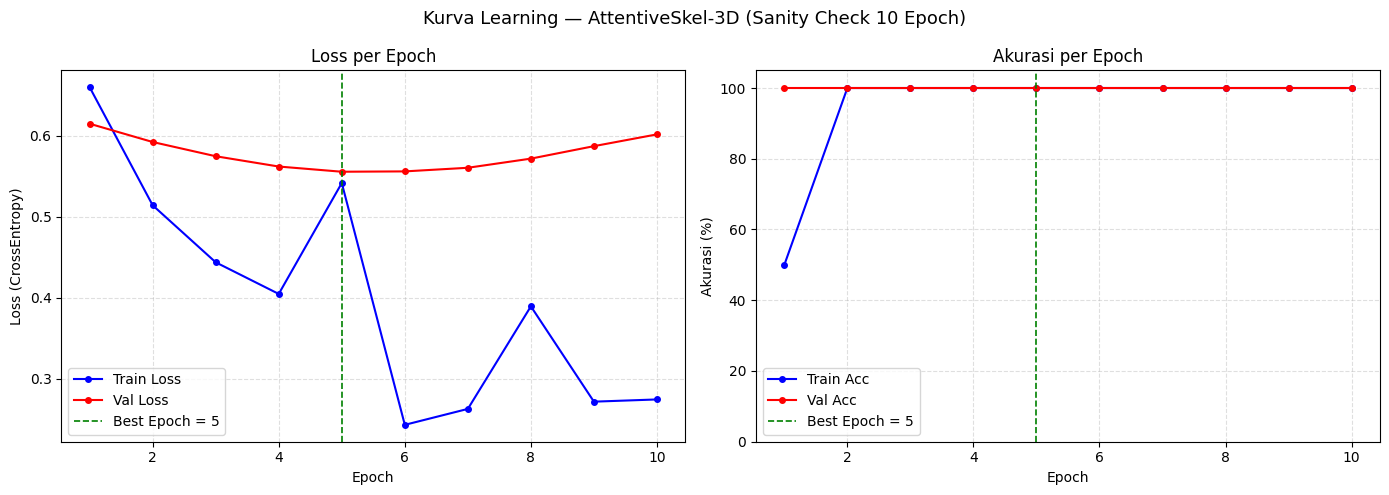


Ringkasan hasil training:
  Train Loss akhir : 0.2748
  Val Loss akhir   : 0.6016
  Train Acc akhir  : 100.00%
  Val Acc akhir    : 100.00%
  Best Epoch       : 5 (Val Loss = 0.5555)


In [9]:
# ============================================================
# Plot kurva loss dan akurasi training vs validasi
# per epoch untuk mendeteksi overfitting / underfitting.
# ============================================================
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kurva Learning — AttentiveSkel-3D (Sanity Check 10 Epoch)", fontsize=13)

# --- Panel kiri: Loss ---
ax_loss = axes[0]
ax_loss.plot(epochs, history["train_loss"], "b-o", markersize=4, label="Train Loss")
ax_loss.plot(epochs, history["val_loss"], "r-o", markersize=4, label="Val Loss")
ax_loss.axvline(
    x=history.get("best_epoch", 1),
    color="green", linestyle="--", linewidth=1.2,
    label=f"Best Epoch = {history.get('best_epoch', 1)}",
)
ax_loss.set_title("Loss per Epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss (CrossEntropy)")
ax_loss.legend()
ax_loss.grid(True, linestyle="--", alpha=0.4)

# --- Panel kanan: Akurasi ---
ax_acc = axes[1]
ax_acc.plot(epochs, [a * 100 for a in history["train_acc"]], "b-o", markersize=4, label="Train Acc")
ax_acc.plot(epochs, [a * 100 for a in history["val_acc"]], "r-o", markersize=4, label="Val Acc")
ax_acc.axvline(
    x=history.get("best_epoch", 1),
    color="green", linestyle="--", linewidth=1.2,
    label=f"Best Epoch = {history.get('best_epoch', 1)}",
)
ax_acc.set_title("Akurasi per Epoch")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Akurasi (%)")
ax_acc.set_ylim(0, 105)
ax_acc.legend()
ax_acc.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nRingkasan hasil training:")
print(f"  Train Loss akhir : {history['train_loss'][-1]:.4f}")
print(f"  Val Loss akhir   : {history['val_loss'][-1]:.4f}")
print(f"  Train Acc akhir  : {history['train_acc'][-1]*100:.2f}%")
print(f"  Val Acc akhir    : {history['val_acc'][-1]*100:.2f}%")
print(f"  Best Epoch       : {history.get('best_epoch', 1)} (Val Loss = {history.get('best_val_loss', 0):.4f})")

### 8. Uji Inferensi: Load Model Terbaik & Prediksi Satu Batch

In [10]:
# ============================================================
# Muat model terbaik dari disk dan jalankan inferensi
# pada satu batch validasi untuk memastikan pipeline
# load → predict berjalan dengan benar.
# ============================================================
# Buat instance model baru (simulasi deployment)
model_loaded = AttentiveSkel3D(num_classes=2).to(DEVICE)

# Muat bobot dari checkpoint
checkpoint = torch.load(SAVED_MODELS_DIR / "best_model.pth", map_location=DEVICE)
model_loaded.load_state_dict(checkpoint["model_state_dict"])
model_loaded.eval()

print(f"Model terbaik berhasil dimuat dari epoch {checkpoint.get('epoch', 'N/A')}.")

# Ambil satu batch dari val_loader dan jalankan inferensi
with torch.no_grad():
    val_batch, val_labels = next(iter(val_loader))
    val_batch = val_batch.to(DEVICE)
    val_labels = val_labels.to(DEVICE)
    
    # Forward pass
    logits = model_loaded(val_batch)
    probs = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1)

label_map = {0: "Benar", 1: "Salah"}

print(f"\nHasil inferensi pada {val_batch.size(0)} sampel val:")
print(f"{'Sampel':>8} {'Label Asli':>12} {'Prediksi':>10} {'P(Benar)':>10} {'P(Salah)':>10} {'Status':>8}")
print("-" * 64)

for i in range(val_batch.size(0)):
    true_lbl = val_labels[i].item()
    pred_lbl = predictions[i].item()
    p_benar = probs[i, 0].item()
    p_salah = probs[i, 1].item()
    
    status = "BENAR" if true_lbl == pred_lbl else "SALAH"
    print(
        f"{i:>8} {label_map[true_lbl]:>12} {label_map[pred_lbl]:>10} "
        f"{p_benar:>10.4f} {p_salah:>10.4f} {status:>8}"
    )

Model terbaik berhasil dimuat dari epoch 5.

Hasil inferensi pada 1 sampel val:
  Sampel   Label Asli   Prediksi   P(Benar)   P(Salah)   Status
----------------------------------------------------------------
       0        Benar      Benar     0.5738     0.4262    BENAR


C:\Users\Administrator\AppData\Local\Temp\ipykernel_28416\3751426113.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVED_MODELS_DIR / "best_mo